In [68]:
import pandas as pd
import numpy as np

In [69]:
features = pd.read_csv(
    '../data/fma_metadata/fma_metadata/features.csv',
    header=[0, 1],
    index_col=0
)


print(features.shape)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15224\3791766483.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  features = pd.read_csv(


(106576, 518)


# Nan vrednosti

Nan vrednosti menjamo medijanom umesto da ih brisemo, da ne bismo ostali bez velikog broja podataka

In [70]:
features = features.fillna(features.median())

Ovde cemo izbaciti sve kolone koje su visak, dakle trazimo grupe kolona koje su jako korelisane (prag nam je 0.95), izbacujemo sve osim jedne

In [71]:
corr = features.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
to_drop

[('chroma_cens', 'median'),
 ('chroma_cens', 'median.1'),
 ('chroma_cens', 'median.2'),
 ('chroma_cens', 'median.3'),
 ('chroma_cens', 'median.4'),
 ('chroma_cens', 'median.5'),
 ('chroma_cens', 'median.6'),
 ('chroma_cens', 'median.7'),
 ('chroma_cens', 'median.8'),
 ('chroma_cens', 'median.9'),
 ('chroma_cens', 'median.10'),
 ('chroma_cens', 'median.11'),
 ('chroma_cqt', 'median'),
 ('chroma_cqt', 'median.1'),
 ('chroma_cqt', 'median.2'),
 ('chroma_cqt', 'median.3'),
 ('chroma_cqt', 'median.4'),
 ('chroma_cqt', 'median.5'),
 ('chroma_cqt', 'median.6'),
 ('chroma_cqt', 'median.7'),
 ('chroma_cqt', 'median.8'),
 ('chroma_cqt', 'median.9'),
 ('chroma_cqt', 'median.10'),
 ('chroma_cqt', 'median.11'),
 ('chroma_stft', 'kurtosis.1'),
 ('chroma_stft', 'kurtosis.10'),
 ('chroma_stft', 'kurtosis.11'),
 ('chroma_stft', 'max.9'),
 ('chroma_stft', 'max.10'),
 ('chroma_stft', 'max.11'),
 ('chroma_stft', 'median'),
 ('chroma_stft', 'median.1'),
 ('chroma_stft', 'median.2'),
 ('chroma_stft', 'media

In [72]:
features_reduced = features.drop(columns=to_drop)

In [73]:
print(features.shape)
print(features_reduced.shape)

(106576, 518)
(106576, 430)


In [123]:
feature_index = features.index

# Standardizujemo podatke

In [74]:
from sklearn.preprocessing import StandardScaler

In [151]:
scaler = StandardScaler()

In [152]:
X = scaler.fit_transform(features_reduced)
X = pd.DataFrame(X, index=features_reduced.index, columns=features_reduced.columns)
X

feature    chroma_cens                                                         \
statistics    kurtosis kurtosis.1 kurtosis.2 kurtosis.3 kurtosis.4 kurtosis.5   
number        0.017346   0.161880   0.267049   0.195536   0.313147   0.466845   
track_id     -0.019097  -0.037847  -0.048835  -0.024185  -0.032802  -0.038417   
2             0.208785   0.452356  -0.008555   0.056481   0.079042   0.017714   
3             0.044880   0.050426   0.001061   0.106159   0.090459  -0.020375   
5             0.002712  -0.024946  -0.061551   0.021788   0.109330   0.046415   
...                ...        ...        ...        ...        ...        ...   
155316       -0.028810   0.023745   0.199114  -0.018593   0.091050   0.147791   
155317       -0.027925  -0.038610  -0.083295  -0.036296  -0.010930  -0.047594   
155318        0.003484  -0.027900  -0.086841  -0.000376  -0.034532  -0.069535   
155319       -0.019108  -0.001129  -0.038612   0.005167  -0.015230  -0.096340   
155320        0.001538   0.149509   0.052077  -0.019605  -0.036251   0.003663   

feature                                                 ...    tonnetz  \
statistics kurtosis.6 kurtosis.7 kurtosis.8 kurtosis.9  ...      std.2   
number       0.396237   0.494957   1.194688   1.188263  ...  74.968545   
track_id    -0.027187  -0.032058  -0.056564  -0.057191  ...  -0.141131   
2            0.071162   0.152165   0.090281   0.129112  ...  -1.552544   
3            0.064402   0.046435  -0.012753   0.040790  ...  -1.237872   
5           -0.070498  -0.081507   0.063088   0.092087  ...  -0.363186   
...               ...        ...        ...        ...  ...        ...   
155316      -0.030123   0.346143   0.085322   0.203800  ...   0.098416   
155317      -0.053115  -0.026971  -0.058594  -0.095224  ...   0.941418   
155318       0.084824   0.069962   0.152518  -0.020230  ...  -0.236223   
155319      -0.062114   0.018809  -0.113108  -0.131244  ...  -0.174092   
155320      -0.037717  -0.019464  -0.140764  -0.176211  ...   0.012977   

feature                                  zcr                                  \
statistics       std.3       std.4  kurtosis       max       mean     median   
number      100.091151  303.269761 -0.319915  3.372715  28.911998  30.039977   
track_id     -0.133501   -0.059690 -0.221969 -0.127921  -0.173563  -0.188062   
2            -1.143689   -0.572024 -0.266429  0.425792   1.003143   0.870150   
3            -0.894674   -0.451037 -0.299407  0.463061   0.971065   0.640104   
5            -1.487348   -0.543695 -0.254633 -0.034748   0.010694  -0.065370   
...                ...         ...       ...       ...        ...        ...   
155316        0.762144    0.056725 -0.281159 -1.136849  -0.732270  -0.479453   
155317        0.878999    0.117671 -0.294395 -1.009069  -0.660744  -0.494789   
155318        0.246839   -0.248285 -0.304666 -0.918558  -0.436897  -0.203398   
155319       -0.266627   -0.200264 -0.261599 -1.166132  -0.344409  -0.172725   
155320       -0.186832   -0.079461 -0.086633  2.528836   0.682997   0.026648   

feature                                      
statistics         min      skew        std  
number      166.541404 -0.727091  35.003713  
track_id     -0.392561 -0.265786  -0.246072  
2            -0.392561 -0.369206   0.770907  
3            -0.392561 -0.491738   1.058398  
5            -0.392561 -0.335242   0.165893  
...                ...       ...        ...  
155316        0.259525 -0.741741  -1.018636  
155317        0.014993 -0.634142  -0.775193  
155318        0.178014 -0.783385  -0.817311  
155319        0.422546 -0.458238  -0.736007  
155320        0.341036  0.483690   3.534065  

[106576 rows x 430 columns]

In [153]:
X.describe()

feature      chroma_cens                                            \
statistics      kurtosis    kurtosis.1    kurtosis.2    kurtosis.3   
count       1.065760e+05  1.065760e+05  1.065760e+05  1.065760e+05   
mean       -1.200061e-18 -1.666751e-19  1.866761e-18  5.333604e-19   
std         1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00   
min        -7.420781e-02 -1.921072e-01 -2.306639e-01 -1.714503e-01   
25%        -3.334633e-02 -7.782236e-02 -9.656804e-02 -4.797216e-02   
50%        -1.909682e-02 -3.784689e-02 -4.883536e-02 -2.418499e-02   
75%         1.394546e-03  1.891492e-02  1.955209e-02  9.254501e-03   
max         2.739014e+02  2.575254e+02  1.780744e+02  2.231682e+02   

feature                                                             \
statistics    kurtosis.4    kurtosis.5    kurtosis.6    kurtosis.7   
count       1.065760e+05  1.065760e+05  1.065760e+05  1.065760e+05   
mean       -4.800244e-18  2.933482e-18 -2.666802e-18  8.000406e-19   
std         1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00   
min        -1.474870e-01 -1.839208e-01 -1.301239e-01 -2.153526e-01   
25%        -6.333421e-02 -7.705744e-02 -5.421639e-02 -6.268383e-02   
50%        -3.280228e-02 -3.841721e-02 -2.718716e-02 -3.205798e-02   
75%         1.050539e-02  1.621543e-02  1.169945e-02  1.232242e-02   
max         2.121567e+02  2.307374e+02  2.521723e+02  2.498448e+02   

feature                                 ...       tonnetz                \
statistics    kurtosis.8    kurtosis.9  ...         std.2         std.3   
count       1.065760e+05  1.065760e+05  ...  1.065760e+05  1.065760e+05   
mean        1.600081e-18 -2.400122e-18  ...  1.152058e-16  3.285500e-16   
std         1.000005e+00  1.000005e+00  ...  1.000005e+00  1.000005e+00   
min        -4.348054e-01 -4.019131e-01  ... -2.557564e+00 -2.386567e+00   
25%        -1.181115e-01 -1.157171e-01  ... -7.265723e-01 -7.045940e-01   
50%        -5.656356e-02 -5.719074e-02  ... -1.411314e-01 -1.335008e-01   
75%         3.129601e-02  2.567262e-02  ...  5.856343e-01  5.722471e-01   
max         1.652588e+02  2.168306e+02  ...  7.496855e+01  1.000912e+02   

feature                            zcr                              \
statistics         std.4      kurtosis           max          mean   
count       1.065760e+05  1.065760e+05  1.065760e+05  1.065760e+05   
mean       -2.005435e-16 -1.280065e-17 -9.813832e-17 -2.986818e-17   
std         1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00   
min        -1.311470e+00 -3.532678e-01 -2.023322e+00 -1.608789e+00   
25%        -2.674302e-01 -2.938802e-01 -7.348749e-01 -6.058599e-01   
50%        -5.968961e-02 -2.219693e-01 -1.279205e-01 -1.735625e-01   
75%         2.055187e-01 -2.791564e-02  4.923442e-01  3.617581e-01   
max         3.032698e+02  9.450548e+01  3.372715e+00  2.891200e+01   

feature                                                             
statistics        median           min          skew           std  
count       1.065760e+05  1.065760e+05  1.065760e+05  1.065760e+05  
mean        5.546948e-17  3.626851e-17  3.840195e-17  1.098722e-16  
std         1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00  
min        -1.368964e+00 -3.925610e-01 -6.220118e+00 -1.454452e+00  
25%        -5.868079e-01 -3.925610e-01 -5.955171e-01 -6.659558e-01  
50%        -1.880615e-01 -3.925610e-01 -2.657856e-01 -2.460722e-01  
75%         3.333760e-01  9.650336e-02  2.841104e-01  3.998748e-01  
max         3.003998e+01  1.665414e+02  2.458559e+01  3.500371e+01  

[8 rows x 430 columns]

# Smanjujemo dimenzionalnost podataka

In [154]:
from sklearn.decomposition import PCA

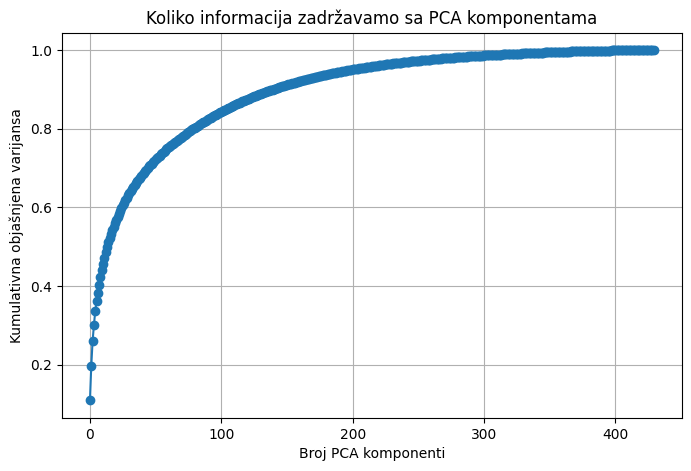

In [155]:
import matplotlib.pyplot as plt


pca = PCA(n_components=X.shape[1])
pca.fit(X)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8,5))
plt.plot(cumulative_var, marker='o')
plt.xlabel('Broj PCA komponenti')
plt.ylabel('Kumulativna objašnjena varijansa')
plt.title('Koliko informacija zadržavamo sa PCA komponentama')
plt.grid(True)
plt.show()

In [156]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [157]:
pca = PCA(n_components=3, random_state=42)
X_3d = pca.fit_transform(X)

In [159]:
import umap

reducer = umap.UMAP(n_components=3, n_neighbors=20, min_dist=0.05, metric='euclidean', random_state=42)
X_umap_3d = reducer.fit_transform(X_3d)

D:\Ip2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


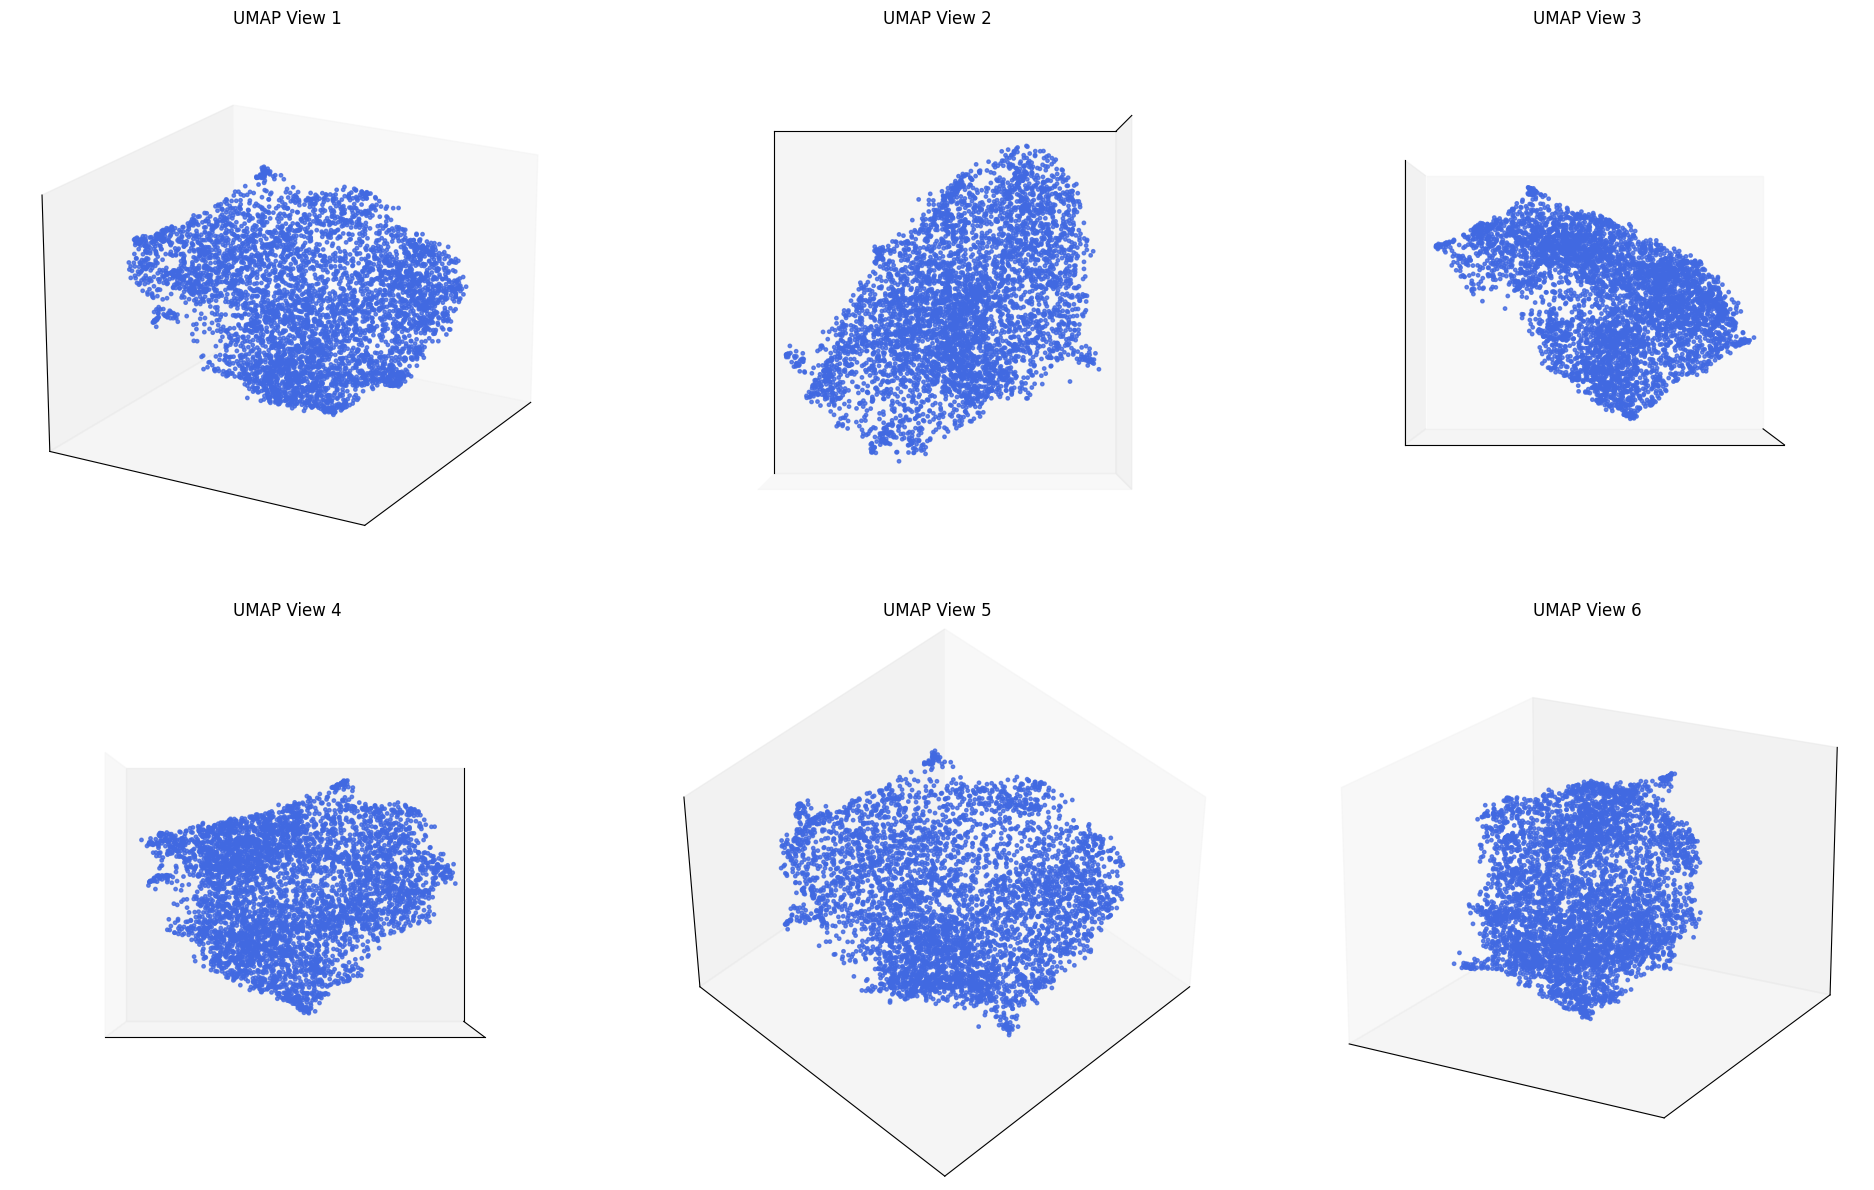

In [170]:
fig = plt.figure(figsize=(20, 12))

viewpoints = [
    (20, 30),
    (90, 0),
    (0, 0),
    (0, 90),
    (45, 45),
    (20, 120)
]

for i, (elev, azim) in enumerate(viewpoints, start=1):
    ax = fig.add_subplot(2, 3, i, projection='3d')

    ax.scatter(
        X_umap_3d[:, 0],
        X_umap_3d[:, 1],
        X_umap_3d[:, 2],
        c='royalblue',
        s=6,
        alpha=0.8
    )

    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f'UMAP View {i}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.grid(False)

plt.tight_layout()
plt.show()

# Koristicemo pca za 25 i 60 komponenata, kao i pca koji cuva 90% varijanse

In [172]:
pca25 = PCA(n_components=25)
X_pca25 = pca25.fit_transform(X)
X_pca25 = pd.DataFrame(pca25.fit_transform(X), index=features.index)

pca60 = PCA(n_components=60)
X_pca60 = pca60.fit_transform(X)
X_pca60 = pd.DataFrame(pca60.fit_transform(X), index=features.index)

pca90 = PCA(n_components=0.9)
X_pca90 = pca90.fit_transform(X)
X_pca90 = pd.DataFrame(pca90.fit_transform(X), index=features.index)

In [173]:
from sklearn.ensemble import IsolationForest

In [174]:
contamination_rate = 0.02

pca_datasets = {
    "PCA25": X_pca25,
    "PCA60": X_pca60,
    "PCA90": X_pca90
}

pca_cleaned = {}

for name, X_data in pca_datasets.items():
    print(f"\n{name}:")

    iso = IsolationForest(contamination=contamination_rate, random_state=42, n_jobs=-1)

    outlier_labels = iso.fit_predict(X_data)
    mask = outlier_labels == 1

    X_clean = X_data[mask]
    pca_cleaned[name] = X_clean

    print("Original size:", X_data.shape)
    print("Cleaned size :", X_clean.shape)
    print("Removed      :", np.sum(outlier_labels == -1))

X_pca25_clean = pca_cleaned["PCA25"]
X_pca60_clean = pca_cleaned["PCA60"]
X_pca90_clean = pca_cleaned["PCA90"]


PCA25:
Original size: (106576, 25)
Cleaned size : (104444, 25)
Removed      : 2132

PCA60:
Original size: (106576, 60)
Cleaned size : (104444, 60)
Removed      : 2132

PCA90:
Original size: (106576, 140)
Cleaned size : (104444, 140)
Removed      : 2132


In [175]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AffinityPropagation, Birch, SpectralClustering
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import OPTICS

In [176]:
param_grid = {

    "GMM": [
        {"n_components": 5, "covariance_type": "full"},
        {"n_components": 8, "covariance_type": "full"},
        {"n_components": 8, "covariance_type": "diag"},
    ],

    "HDBSCAN": [
        {"min_cluster_size": 5, "min_samples": 5},
        {"min_cluster_size": 10, "min_samples": 10},
        {"min_cluster_size": 15, "min_samples": 5},
    ],

    "OPTICS": [
        {"min_samples": 5, "xi": 0.05},
        {"min_samples": 10, "xi": 0.05},
        {"min_samples": 10, "xi": 0.1},
    ],

    "Birch": [
        {"threshold": 0.5, "n_clusters": None},
        {"threshold": 0.3, "n_clusters": None},
        {"threshold": 0.5, "n_clusters": 8},
    ],

    "Agglomerative": [
        {"n_clusters": 5, "linkage": "ward"},
        {"n_clusters": 8, "linkage": "ward"},
        {"n_clusters": 8, "linkage": "average"},
    ],

    "Spectral": [
        {"n_clusters": 5, "affinity": "nearest_neighbors"},
        {"n_clusters": 8, "affinity": "nearest_neighbors"},
    ]
}

In [178]:
sample_size = 10000
indices = np.random.choice(X_pca90.shape[0], size=sample_size, replace=False)
X_sample = X_pca90.iloc[indices]

In [179]:
from sklearn.metrics import calinski_harabasz_score
from dbcv import dbcv

In [180]:
def run_clustering(X, algorithm, use_sample=False, sample_size=10000):

    if use_sample:
        idx = np.random.choice(len(X), sample_size, replace=False)
        X_use = X.iloc[idx]
    else:
        X_use = X

    labels = (
        algorithm.fit_predict(X_use)
        if hasattr(algorithm, "fit_predict")
        else algorithm.fit(X_use).labels_
    )

    results = {}

    mask = labels != -1
    if len(set(labels[mask])) > 1:
        results["silhouette"] = silhouette_score(X_use[mask], labels[mask])
        results["calinski_harabasz"] = calinski_harabasz_score(X_use[mask], labels[mask])
    else:
        results["silhouette"] = np.nan
        results["calinski_harabasz"] = np.nan

    try:
        results["dbcv"] = dbcv(X_use.values, labels)
    except:
        results["dbcv"] = np.nan

    return results

In [182]:
results = []

for name, param_list in param_grid.items():
    for params in param_list:
        for pca_name, X_data in pca_cleaned.items():

            if name == "GMM":
                alg = GaussianMixture(random_state=42, **params)
            elif name == "HDBSCAN":
                alg = HDBSCAN(**params)
            elif name == "Birch":
                alg = Birch(**params)
            elif name == "Agglomerative":
                alg = AgglomerativeClustering(**params)
            elif name == "OPTICS":
                alg = OPTICS(**params)
            elif name == "Spectral":
                alg = SpectralClustering(**params)

            res = run_clustering(
                X_data,
                alg,
                use_sample=True,
                sample_size=8000
            )

            res["algorithm"] = name
            res["pca"] = pca_name
            res["params"] = str(params)

            results.append(res)

results_df = pd.DataFrame(results)

D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `cop

In [183]:
results_df

,silhouette,calinski_harabasz,dbcv,algorithm,pca,params
0,0.001791,3.458136e+02,NaN,GMM,PCA25,"{'n_components': 5, 'covariance_type': 'full'}"
1,0.011640,3.127423e+02,NaN,GMM,PCA60,"{'n_components': 5, 'covariance_type': 'full'}"
2,0.014247,2.635480e+02,NaN,GMM,PCA90,"{'n_components': 5, 'covariance_type': 'full'}"
3,-0.021557,2.946355e+02,NaN,GMM,PCA25,"{'n_components': 8, 'covariance_type': 'full'}"
4,-0.016950,2.524164e+02,NaN,GMM,PCA60,"{'n_components': 8, 'covariance_type': 'full'}"
5,0.018835,2.573567e+02,NaN,GMM,PCA90,"{'n_components': 8, 'covariance_type': 'full'}"
6,-0.035076,2.382696e+02,NaN,GMM,PCA25,"{'n_components': 8, 'covariance_type': 'diag'}"
7,-0.067358,1.403680e+02,NaN,GMM,PCA60,"{'n_components': 8, 'covariance_type': 'diag'}"
8,-0.078717,9.527759e+01,NaN,GMM,PCA90,"{'n_components': 8, 'covariance_type': 'diag'}"
9,0.200389,9.774854e+01,NaN,HDBSCAN,PCA25,"{'min_cluster_size': 5, 'min_samples': 5}"


In [184]:
results_df.groupby(["pca", "algorithm"])["silhouette"].max().sort_values(ascending=False)

pca    algorithm    
PCA25  OPTICS           0.590082
PCA60  OPTICS           0.589063
PCA90  OPTICS           0.565879
PCA25  HDBSCAN          0.499643
PCA60  HDBSCAN          0.471433
PCA90  HDBSCAN          0.422485
       Agglomerative    0.354511
PCA60  Agglomerative    0.263176
PCA25  Agglomerative    0.228625
       Spectral         0.098991
PCA60  Spectral         0.080112
PCA90  Spectral         0.060444
       GMM              0.018835
PCA60  Birch            0.018515
PCA25  Birch            0.017103
PCA60  GMM              0.011640
PCA90  Birch            0.009085
PCA25  GMM              0.001791
Name: silhouette, dtype: float64

Posto gmm i birch imaju lose silhouette skorove (~ 0) oni otpadaju u daljoj analizi

In [186]:
sample_size = 5000

idx = np.random.choice(len(X_pca25_clean), sample_size, replace=False)
X_sample = X_pca60_clean.iloc[idx]

best_optics = OPTICS(min_samples=5, xi=0.05)

labels = best_optics.fit_predict(X_sample)

In [187]:
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(4979), np.int64(0): np.int64(6), np.int64(1): np.int64(10), np.int64(2): np.int64(5)}


znaci da smo racunali silhuette score nad nekim malim brojem tacaka i zato je tako visok, ostalo je noise

D:\Ip2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


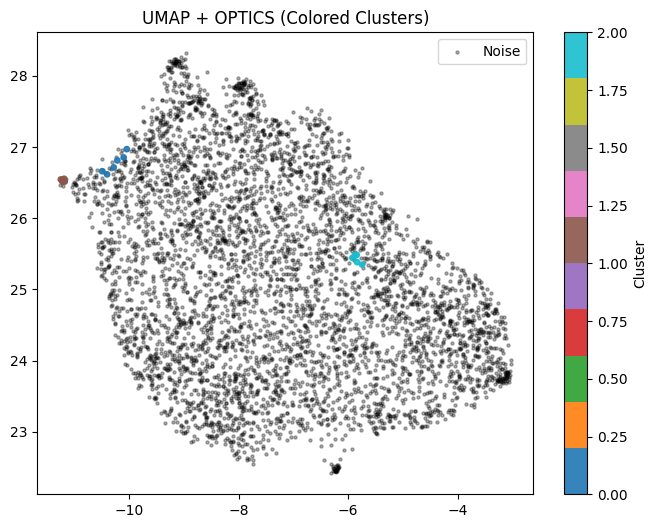

In [188]:
import matplotlib.pyplot as plt
import numpy as np
import umap

reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.05, random_state=42)

X_umap_2d = reducer.fit_transform(X_sample)

noise_mask = labels == -1
cluster_mask = labels != -1

plt.figure(figsize=(8,6))


plt.scatter(X_umap_2d[noise_mask, 0], X_umap_2d[noise_mask, 1], c="black", s=5, alpha=0.3, label="Noise")

scatter = plt.scatter(X_umap_2d[cluster_mask, 0], X_umap_2d[cluster_mask, 1], c=labels[cluster_mask], cmap="tab10", s=15, alpha=0.9)

plt.title("UMAP + OPTICS (Colored Clusters)")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.show()

Iz ovoga se moze videti da globalna klaster struktura ne postoji, nas optics je nasao samo par lokalno gustih regija.

Rezultat je da algoritmi klasterovanja po gustini hvataju male lokalne regije

In [189]:
hdb_best = HDBSCAN(min_cluster_size=15, min_samples=5)

labels_hdb = hdb_best.fit_predict(X_sample)

D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [190]:
unique, counts = np.unique(labels_hdb, return_counts=True)

print("Clusters and sizes:")
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")

num_clusters = len(unique) - (1 if -1 in unique else 0)
num_noise = counts[unique.tolist().index(-1)] if -1 in unique else 0

print("\nNumber of clusters:", num_clusters)
print("Noise points:", num_noise)
print("Noise percentage:", num_noise / len(labels_hdb) * 100)

Clusters and sizes:
Cluster -1: 5000

Number of clusters: 0
Noise points: 5000
Noise percentage: 100.0


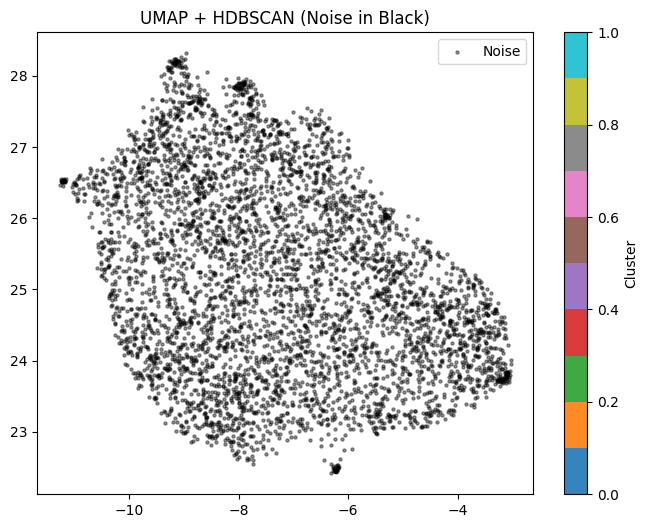

In [191]:
plt.figure(figsize=(8,6))

noise_mask = labels_hdb == -1
cluster_mask = labels_hdb != -1

plt.scatter(X_umap_2d[noise_mask, 0], X_umap_2d[noise_mask, 1], c="black", s=5, alpha=0.4, label="Noise")

scatter = plt.scatter(X_umap_2d[cluster_mask, 0], X_umap_2d[cluster_mask, 1], c=labels_hdb[cluster_mask], cmap="tab10", s=20, alpha=0.9)

plt.title("UMAP + HDBSCAN (Noise in Black)")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.show()

Iz ovoga vidimo da ne postoji prirodna viseklaster struktura.

Mozemo da zakljucimo da:
 1. Dataset nema jaku centroid strukturu
2. Nema jasnu hijerarhijsku strukturu
3. Ima jednu dominantnu gustinsku regiju
4. Ima par lokalnih gustih ostrva

In [192]:
hdb_alt1 = HDBSCAN(min_cluster_size=8, min_samples=3)

labels_alt1 = hdb_alt1.fit_predict(X_sample)

D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [193]:
hdb_alt2 = HDBSCAN(min_cluster_size=10, min_samples=3)

labels_alt2 = hdb_alt2.fit_predict(X_sample)

D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [194]:
def analyze_labels(labels):
    unique, counts = np.unique(labels, return_counts=True)

    print("Clusters and sizes:")
    for u, c in zip(unique, counts):
        print(f"Cluster {int(u)}: {int(c)}")

    num_clusters = len(unique) - (1 if -1 in unique else 0)

    if -1 in unique:
        noise_count = int(counts[unique.tolist().index(-1)])
    else:
        noise_count = 0

    noise_percent = noise_count / len(labels) * 100

    print("\nSummary:")
    print(f"Number of clusters: {num_clusters}")
    print(f"Noise points: {noise_count}")
    print(f"Noise percentage: {noise_percent:.2f}%")

In [195]:
analyze_labels(labels_alt1)
analyze_labels(labels_alt2)

Clusters and sizes:
Cluster -1: 1691
Cluster 0: 3294
Cluster 1: 15

Summary:
Number of clusters: 2
Noise points: 1691
Noise percentage: 33.82%
Clusters and sizes:
Cluster -1: 1691
Cluster 0: 3294
Cluster 1: 15

Summary:
Number of clusters: 2
Noise points: 1691
Noise percentage: 33.82%


Pokusaj promene parametara za hdbscan ne dobija bolja resenja od prethodnog, uvek dobijamo 1 dominantan klaster i mali gusti klaster (ili 2)

In [215]:
hdb_best = HDBSCAN(min_cluster_size=10, min_samples=3)

labels_best = hdb_best.fit_predict(X_sample)
analyze_labels(labels_best)

D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Clusters and sizes:
Cluster -1: 1691
Cluster 0: 3294
Cluster 1: 15

Summary:
Number of clusters: 2
Noise points: 1691
Noise percentage: 33.82%


In [216]:
tracks = pd.read_csv('../data/fma_metadata/fma_metadata/tracks.csv', header=[0, 1], index_col=0)
genres = tracks[('track', 'genre_top')]

In [217]:
sample_ids = X_sample.index.astype(int)
sample_genres = genres.loc[sample_ids]

In [218]:
analysis_df = pd.DataFrame({"cluster": labels_best, "genre": sample_genres})

In [219]:
for cluster_id in sorted(analysis_df["cluster"].unique()):
    print(f"\nCluster {cluster_id}")
    print(analysis_df[analysis_df["cluster"] == cluster_id]["genre"].value_counts(normalize=True).head(5))


Cluster -1
genre
Experimental    0.295794
Electronic      0.240163
Rock            0.137042
Instrumental    0.078697
Pop             0.065129
Name: proportion, dtype: float64

Cluster 0
genre
Rock            0.354061
Experimental    0.176396
Electronic      0.164340
Hip-Hop         0.072335
Folk            0.055838
Name: proportion, dtype: float64

Cluster 1
genre
Old-Time / Historic    1.0
Name: proportion, dtype: float64


Izgleda da za razliku od klastera -1 i 0,klaster 1 zapravo sadrzi Old-Time / Historic zanr, i to samo njega

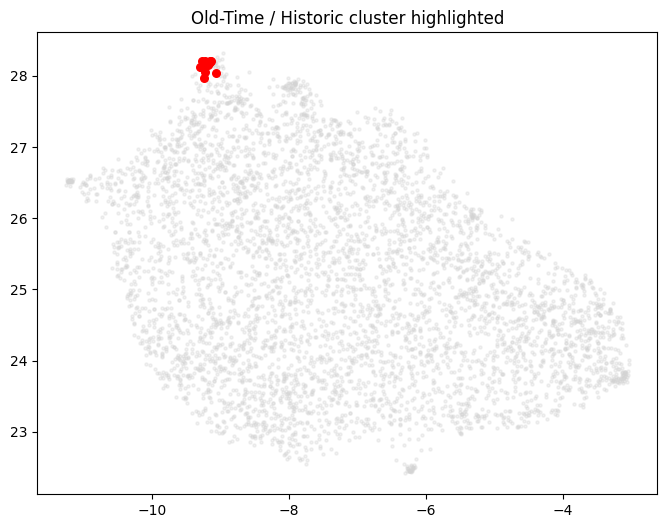

In [222]:
mask_cluster1 = labels_best == 1

plt.figure(figsize=(8,6))
plt.scatter(X_umap_2d[:,0], X_umap_2d[:,1], c='lightgray', s=5, alpha=0.3)
plt.scatter(X_umap_2d[mask_cluster1,0], X_umap_2d[mask_cluster1,1], c='red', s=30)
plt.title("Old-Time / Historic cluster highlighted")
plt.show()

Nakon ovoga pokusacemo i AgglomerativeClustering,cisto da pokusamo sa hijerarhijskim klasterovanjem

In [223]:
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg.fit_predict(X_sample)

In [224]:
analyze_labels(labels_agg)

Clusters and sizes:
Cluster 0: 1578
Cluster 1: 2236
Cluster 2: 1186

Summary:
Number of clusters: 3
Noise points: 0
Noise percentage: 0.00%


In [225]:
analysis_df_agg = pd.DataFrame({
    "cluster": labels_agg,
    "genre": sample_genres
})

for cluster_id in sorted(analysis_df_agg["cluster"].unique()):
    print(f"\nCluster {cluster_id}")
    print(
        analysis_df_agg[analysis_df_agg["cluster"] == cluster_id]["genre"]
        .value_counts(normalize=True)
        .head(5)
    )


Cluster 0
genre
Experimental    0.237872
Folk            0.128326
Rock            0.128326
Electronic      0.114241
Classical       0.097027
Name: proportion, dtype: float64

Cluster 1
genre
Rock            0.442722
Experimental    0.201550
Electronic      0.135228
Hip-Hop         0.062877
Pop             0.054264
Name: proportion, dtype: float64

Cluster 2
genre
Electronic      0.390892
Experimental    0.208729
Hip-Hop         0.132827
Rock            0.119545
Pop             0.056926
Name: proportion, dtype: float64


Izgleda da algoritam ne moze da izdvoji klaster poput ranijeg pristupa sa gustinom, pokusacemo i sa OPTICS-om da izvucemo isti klaster

In [229]:
optics = OPTICS(min_samples=3, xi=0.03, min_cluster_size=8)
labels_optics = optics.fit_predict(X_sample)

In [230]:
analyze_labels(labels_optics)

Clusters and sizes:
Cluster -1: 4983
Cluster 0: 8
Cluster 1: 9

Summary:
Number of clusters: 2
Noise points: 4983
Noise percentage: 99.66%


In [231]:
analysis_df_optics = pd.DataFrame({
    "cluster": labels_optics,
    "genre": sample_genres
})

for cluster_id in sorted(analysis_df_optics["cluster"].unique()):
    print(f"\nCluster {cluster_id}")
    print(
        analysis_df_optics[analysis_df_optics["cluster"] == cluster_id]["genre"]
        .value_counts(normalize=True)
        .head(5)
    )


Cluster -1
genre
Rock            0.282084
Experimental    0.213609
Electronic      0.187769
Hip-Hop         0.066322
Pop             0.052541
Name: proportion, dtype: float64

Cluster 0
genre
Rock    0.8
Pop     0.2
Name: proportion, dtype: float64

Cluster 1
Series([], Name: proportion, dtype: float64)


Old-Time region je detektabilan kroz HDBSCAN-ovu hijerarhiju gustine, ali nije dovoljno robustan da bude identifikovan drugim clustering paradigmama.

Naravno,posto je ovo samo sample,provericemo da li smo samo "imali srece" ili taj mali klaster stvarno postoji

In [240]:
X_pca60_clean = X_pca60_clean[X_pca60_clean.index != "track_id"]
X_pca60_clean.index = X_pca60_clean.index.astype(int)

In [241]:
reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.05, random_state=42)

X_umap_full = reducer.fit_transform(X_pca60_clean)

D:\Ip2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [242]:
all_ids = X_pca60_clean.index.astype(int)
all_genres = genres.reindex(all_ids)

In [243]:
mask_oldtime = all_genres == "Old-Time / Historic"

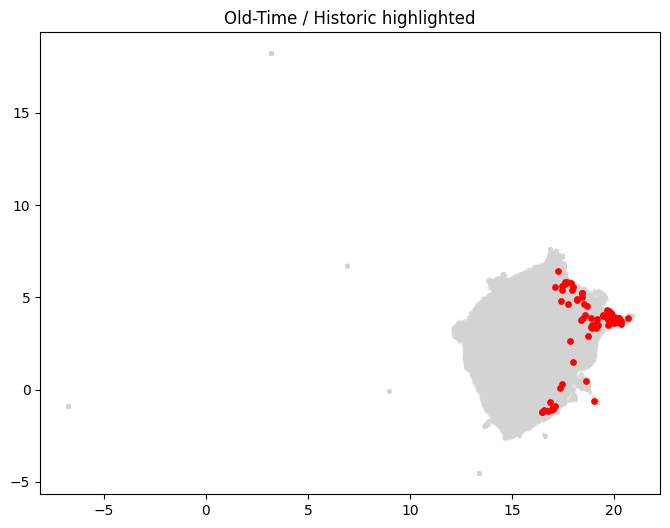

In [244]:
plt.figure(figsize=(8,6))

plt.scatter(X_umap_full[:,0], X_umap_full[:,1], c='lightgray', s=5, alpha=0.3)

plt.scatter(X_umap_full[mask_oldtime,0], X_umap_full[mask_oldtime,1], c='red', s=15)

plt.title("Old-Time / Historic highlighted")
plt.show()

Old-Time:

Nije zasebno "ostrvo", ali ima gust lokalni region koji HDBSCAN uspeva da izoluje, dok globalni algoritmi ne uspevaju

Izracunacemo prosecnu medjusobnu udaljenost izmedju Old-Time tacaka
i uporediti je sa prosecnom udaljenoscu nasumicnih tacaka iz skupa.

In [245]:
from sklearn.metrics import pairwise_distances

In [246]:
mask_oldtime = (all_genres == "Old-Time / Historic").values

X_old = X_pca60_clean.values[mask_oldtime]

dist_old = pairwise_distances(X_old)
mean_old = dist_old[np.triu_indices_from(dist_old, k=1)].mean()

n_old = X_old.shape[0]
idx_random = np.random.choice(len(X_pca60_clean), n_old, replace=False)
X_random = X_pca60_clean.values[idx_random]

dist_random = pairwise_distances(X_random)
mean_random = dist_random[np.triu_indices_from(dist_random, k=1)].mean()

print("Mean distance Old-Time:", mean_old)
print("Mean distance Random :", mean_random)
print("Ratio (Old / Random):", mean_old / mean_random)

Mean distance Old-Time: 17.50207657101287
Mean distance Random : 20.440024709522206
Ratio (Old / Random): 0.8562649419332327


In [247]:
ratios = []

for _ in range(10):
    idx_random = np.random.choice(len(X_pca60_clean), n_old, replace=False)
    X_random = X_pca60_clean.values[idx_random]
    dist_random = pairwise_distances(X_random)
    mean_random = dist_random[np.triu_indices_from(dist_random, k=1)].mean()
    ratios.append(mean_old / mean_random)

print("Average ratio over 10 runs:", np.mean(ratios))

Average ratio over 10 runs: 0.8628922524890683


Old-Time / Historic pokazuje konzistentnu lokalnu kompaktnost u visoko-dimenzionalnom PCA prostoru (≈14% manja prosecna medjusobna udaljenost u odnosu na random podskup), ali ne formira globalno separabilnu strukturu. Gustinski algoritmi (HDBSCAN) uspevaju da identifikuju ovaj lokalni region, dok globalni pristupi ne detektuju jasnu segmentaciju.